# Notebook 3 — Feature Selection & Engineering

**Goal**: Starting from the target-labelled dataset , engineer features
<br> run correlation analysis, split temporally, then apply WoE encoding
<br> for the Logistic Regression


### **Sections**:
   1. Load Data
   2. Feature engineering
   3. Correlation analysis
   4. Temporal train/val/OOT split
   5. WoE/IV computation & feature selection
   6. WoE transformation & VIF check
   7. Save model-ready datasets

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import sys, os

# Add project / to path
sys.path.insert(0, os.path.abspath('../'))

from src.utils.config import (
    PATHS, TARGET_COL, SPLIT_DATES,
    LEAKAGE_COLUMNS, CONTINUOUS_FEATURES, CATEGORICAL_FEATURES,
    CORRELATED_DROP, IV_THRESHOLD, VIF_THRESHOLD,
)
from src.utils.features import (
    engineer_features,
    drop_leakage,
    find_correlated_pairs,
    plot_correlation_heatmap,
    temporal_split,
)
from src.utils.woe import (
    fit_woe,
    select_by_iv,
    transform_woe,
    check_vif,
    woe_detail_table,
    woe_detail_all,
    plot_woe,
    plot_woe_grid,
    tree_bin_edges,
    compute_woe_with_edges,
)

# 1. Load Data

In [2]:
df_model = pd.read_parquet(PATHS['target_built'])
print(f"Loaded: {len(df_model):,} rows × {df_model.shape[1]} columns")

Loaded: 145,029 rows × 45 columns


In [3]:
# Separate LoanDate before dropping — needed for split, NOT as a feature
loan_dates = df_model['LoanDate'].copy()

In [4]:
# Drop LoanDate from features (it's stored separately)
df_model.drop(columns=['LoanDate'], inplace=True, errors='ignore')

# 2. Feature Engineering

Two derived features ideas:
- **loan_to_income**: how large is the loan vs monthly income?

- **approval_ratio**: A ratio of how much loan was given vs how much was applied by the borrower ?

Formula:

$$
\begin{aligned}
&\text{LoanToIncome} = \frac{\text{Amount}}{\text{IncomeTotal}} 
\\
\\
&\text{ApprovalRatio} = \frac{\text{Amount}}{\text{AppliedAmount}}
\end{aligned}
$$

In [5]:
df_model = engineer_features(df_model)

Engineered features: loan_to_income, approval_ratio


In [6]:
feature_cols = [c for c in df_model.columns if c != TARGET_COL]
print(f"Features after addtional variable created: {len(feature_cols)}")

Features after addtional variable created: 45


# 3. Correlation Analysis

In [7]:
corr_pairs = find_correlated_pairs(df_model, feature_cols)


Highly correlated pairs (|r| > 0.7): 5
                        Feature 1                              Feature 2  Correlation
                    AppliedAmount                                 Amount       0.9655
                    AppliedAmount                         MonthlyPayment       0.8869
                           Amount                         MonthlyPayment       0.8473
      NoOfPreviousLoansBeforeLoan        AmountOfPreviousLoansBeforeLoan       0.7522
PreviousEarlyRepaymentsBefoleLoan PreviousEarlyRepaymentsCountBeforeLoan       0.7259


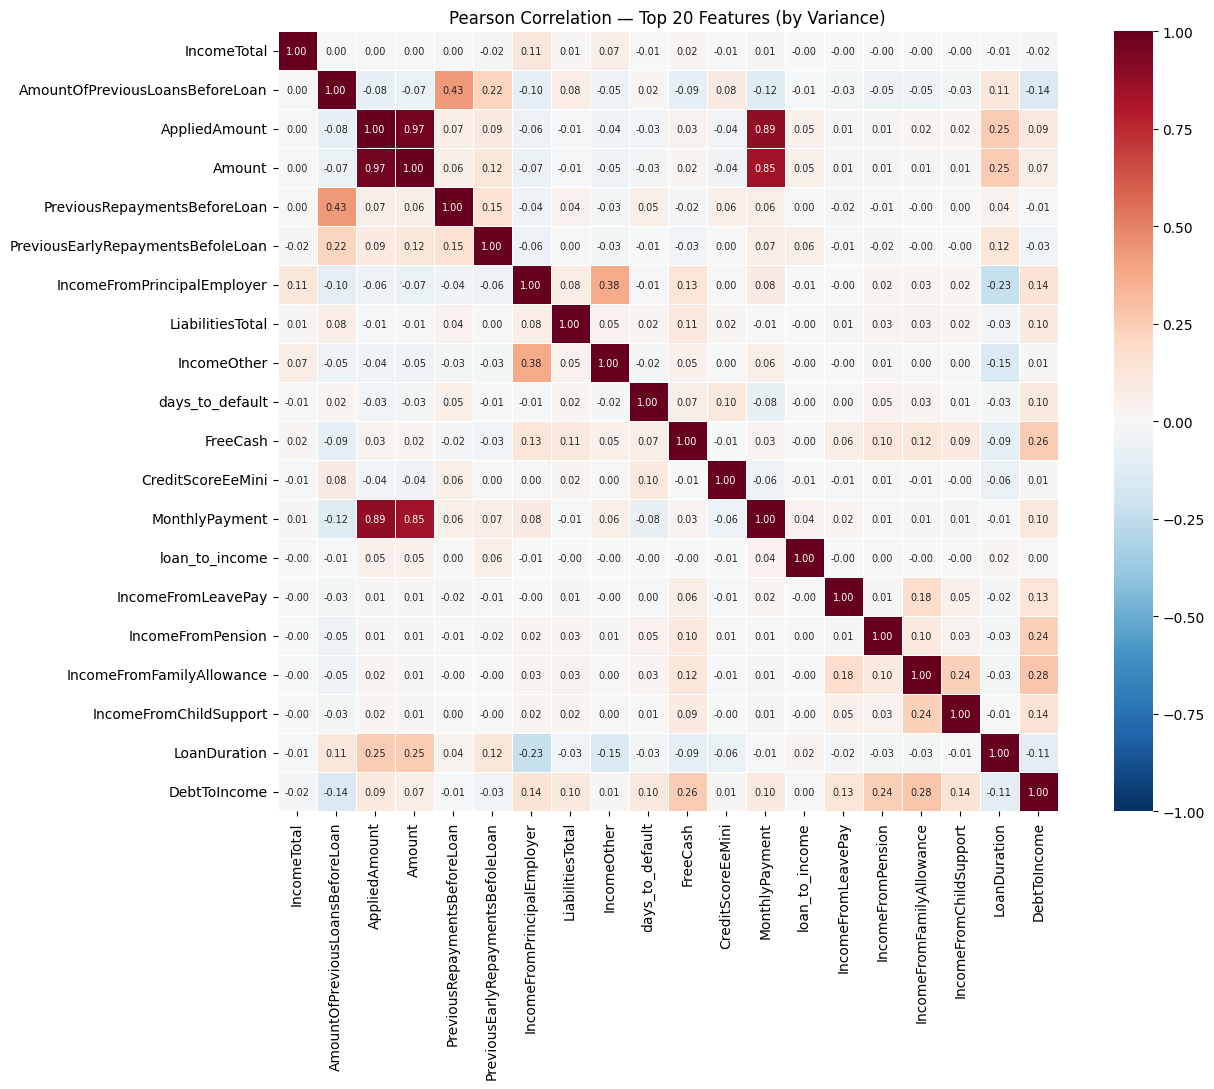

In [8]:
fig = plot_correlation_heatmap(df_model, feature_cols, top_n=20)
fig.savefig(PATHS['reports_dir'] / 'figures' / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')


# Drop correlated features

| Dropped | Reason |
|---|---|
| AppliedAmount | r=0.96 with Amount |
| MonthlyPayment | r=0.88 with AppliedAmount |
| NoOfPreviousLoansBeforeLoan | r=0.75 with AmountOfPreviousLoans |
| PreviousEarlyRepaymentsCountBeforeLoan | r=0.72 with PreviousEarlyRepayments |

In [9]:
to_drop = [c for c in CORRELATED_DROP if c in df_model.columns]
df_model.drop(columns=to_drop, inplace=True)
feature_cols = [c for c in df_model.columns if c != TARGET_COL]
print(f"Dropped {len(to_drop)} correlated features numeric variables→ {len(feature_cols)} remaining")

Dropped 4 correlated features numeric variables→ 41 remaining


In [ ]:
from src.utils.features import cramers_v
# Run only on the categorical features that are still present after leakage drop
cat_cols_present = [c for c in CATEGORICAL_FEATURES if c in df_model.columns]

cv_matrix = pd.DataFrame(np.zeros((len(cat_cols_present), len(cat_cols_present))),
                         index=cat_cols_present, columns=cat_cols_present)

for c1 in cat_cols_present:
    for c2 in cat_cols_present:
        cv_matrix.loc[c1, c2] = cramers_v(df_model[c1].astype(str),
                                           df_model[c2].astype(str))

print("Cramér's V matrix (categorical-categorical):")
print(cv_matrix.round(2).to_string())

Cramér's V matrix (categorical–categorical):
                                   NewCreditCustomer  VerificationType  LanguageCode  Gender  Education  MaritalStatus  EmploymentStatus  EmploymentDurationCurrentEmployer  OccupationArea  HomeOwnershipType  UseOfLoan
NewCreditCustomer                               1.00              0.12          0.05    0.05       0.07           0.04              0.05                               0.12            0.08               0.07       0.11
VerificationType                                0.12              1.00          0.05    0.11       0.51           0.50              0.29                               0.16            0.43               0.22       0.52
LanguageCode                                    0.05              0.05          1.00    0.03       0.07           0.07              0.09                               0.04            0.11               0.08       0.06
Gender                                          0.05              0.11          0.0

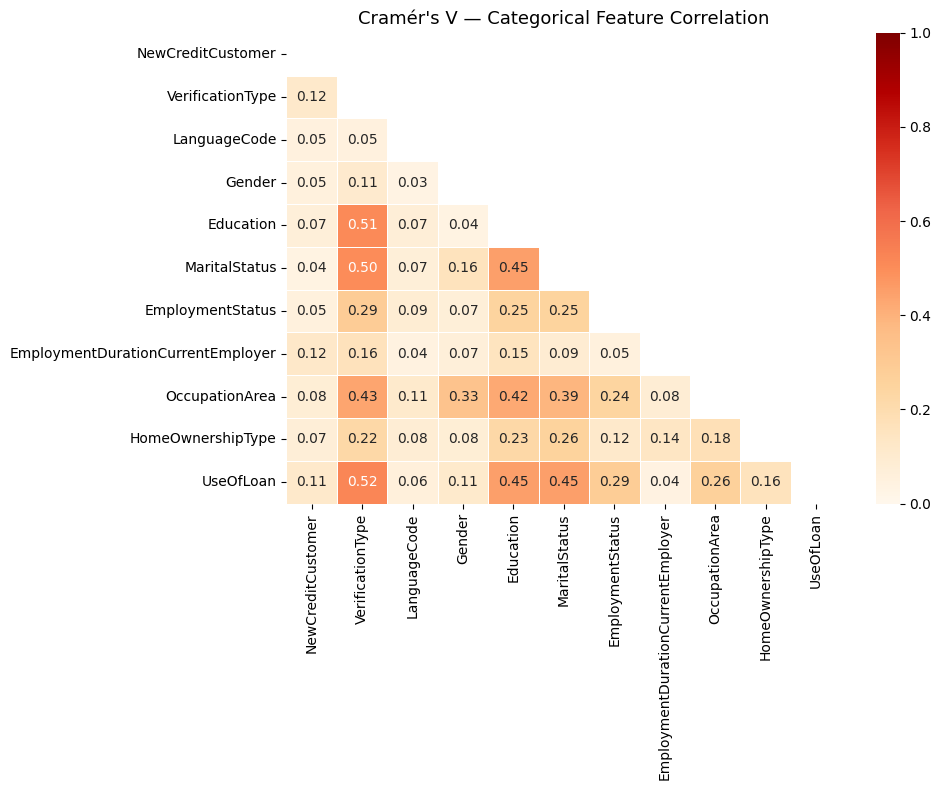

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(cv_matrix, dtype=bool))   # upper triangle only
sns.heatmap(
    cv_matrix.astype(float),
    mask=mask,
    annot=True, fmt='.2f',
    cmap='OrRd', vmin=0, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title("Cramér's V — Categorical Feature Correlation", fontsize=13)
plt.tight_layout()
fig.savefig(PATHS['reports_dir'] / 'figures' / 'cramers_v_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Flag pairs above threshold ──────────────────────────────────────────────
CV_THRESHOLD = 0.7   # adjust — 0.5 is moderate, 0.7 is strong

high_cv_pairs = []
for i, c1 in enumerate(cat_cols_present):
    for j, c2 in enumerate(cat_cols_present):
        if j <= i:          # lower triangle only, skip diagonal
            continue
        v = cv_matrix.loc[c1, c2]
        if v >= CV_THRESHOLD:
            high_cv_pairs.append({'Feature_A': c1, 'Feature_B': c2, 'CramersV': round(v, 3)})



In [12]:
print(f'Total correlation categorical featuers found : {high_cv_pairs}')

Total correlation categorical featuers found : []


# 4. Temporal Split
We split by LoanDate not randomly because credit risk is temporal:
<br>the model should only see past data at scoring time.

| Split | Period | Purpose |
|---|---|---|
| Train | ≤ 2021-06-30 | Fit models |
| Val | 2021-07-01 to 2021-12-31 | Tune hyperparams, calibrate |
| OOT | 2022-01-01 + | Final evaluation (never touched during training) |

## Why temporal Split ?



To stop the model peaking into the future data

In [13]:
splits = temporal_split(
    df_model,
    loan_dates=loan_dates,
    target_col=TARGET_COL,
    feature_cols=feature_cols,
    train_end=SPLIT_DATES['train_end'],
    val_end=SPLIT_DATES['val_end'],
)

  TRAIN:  109,035  |  Default rate: 15.65%
  VAL  :   16,348  |  Default rate: 13.48%
  OOT  :   19,646  |  Default rate: 15.16%


In [14]:
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_oot,   y_oot   = splits['X_oot'],   splits['y_oot']

# 5. WoE / IV Computation

Weight of Evidence encodes each feature into a single score that
<br>represents its log-odds relationship with default. Fitted on training
<br>data ONLY, then applied to val/OOT.

Information Value tells us how predictive each feature is:
- IV < 0.02 → not useful (drop)
- 0.02 – 0.1 → weak predictor
- 0.1 – 0.3 → medium predictor
- IV > 0.3 → strong (check for leakage if > 0.5)

In [15]:
woe_rules, iv_df = fit_woe(
    X_train, y_train,
    continuous_cols=CONTINUOUS_FEATURES,
    categorical_cols=CATEGORICAL_FEATURES,
)


--- Computing WoE / IV on Training Set (Binning: quantile) ---
  Age                                      IV = 0.0781
  Amount                                   IV = 0.0409
  Interest                                 IV = 0.1485
  LoanDuration                             IV = 0.0303
  IncomeTotal                              IV = 0.0129
  LiabilitiesTotal                         IV = 0.0222
  DebtToIncome                             IV = 0.0015
  FreeCash                                 IV = 0.0038
  ExistingLiabilities                      IV = 0.0240
  RefinanceLiabilities                     IV = 0.0000
  AmountOfPreviousLoansBeforeLoan          IV = 0.0441
  PreviousRepaymentsBeforeLoan             IV = 0.0802
  CreditScoreEeMini                        IV = 0.0683
  loan_to_income                           IV = 0.0254
  approval_ratio                           IV = 0.0004
  NewCreditCustomer                        IV = 0.0446
  VerificationType                         IV = 0.0274
 

In [16]:
woe_rules.keys()

dict_keys(['Age', 'Amount', 'Interest', 'LoanDuration', 'IncomeTotal', 'LiabilitiesTotal', 'DebtToIncome', 'FreeCash', 'ExistingLiabilities', 'RefinanceLiabilities', 'AmountOfPreviousLoansBeforeLoan', 'PreviousRepaymentsBeforeLoan', 'CreditScoreEeMini', 'loan_to_income', 'approval_ratio', 'NewCreditCustomer', 'VerificationType', 'LanguageCode', 'Gender', 'Education', 'MaritalStatus', 'EmploymentStatus', 'EmploymentDurationCurrentEmployer', 'OccupationArea', 'HomeOwnershipType', 'UseOfLoan'])

In [17]:
# Show top 10 featuers sorted by IV
iv_df.sort_values('IV', ascending=False).head(10)

,Variable,IV,Type
2,Interest,0.148512,Continuous
24,HomeOwnershipType,0.085655,Categorical
11,PreviousRepaymentsBeforeLoan,0.080159,Continuous
0,Age,0.078116,Continuous
12,CreditScoreEeMini,0.068318,Continuous
23,OccupationArea,0.062040,Categorical
19,Education,0.050095,Categorical
22,EmploymentDurationCurrentEmployer,0.049047,Categorical
20,MaritalStatus,0.048926,Categorical
15,NewCreditCustomer,0.044575,Categorical


 ## 5A. WoE — Fine_Coarse Binning

In [18]:
# Check the list of variables and then update in config.py , for now it is updated

# iv_df[iv_df['Type'] == "Continuous"]['Variable'].to_list()
# iv_df[iv_df['Type'] == "Categorical"]['Variable'].to_list()

In [19]:
selected_vars = select_by_iv(iv_df, threshold=IV_THRESHOLD)

# Build detailed WoE tables for selected continuous variables
cont_selected = [c for c in selected_vars if c in CONTINUOUS_FEATURES and c in X_train.columns]
cat_selected = [c for c in selected_vars if c in CATEGORICAL_FEATURES and c in X_train.columns]

detail_tables = woe_detail_all(X_train, y_train, cont_selected, cat_selected)
# Show detail for top feature by IV
top_var = iv_df.iloc[0]['Variable']
if top_var in detail_tables:
    print(f"\n--- WoE Detail: {top_var} ---")
    print(detail_tables[top_var].to_string(index=False))



Selected features (IV >= 0.02): 19 of 26

--- WoE Detail: Interest ---
      Interest  n_obs  prop_bad  prop_good  prop_n_obs  n_good  n_bad  prop_n_good  prop_n_bad       WoE   IV_bin  diff_prop_good  diff_WoE  IV_total
(1.999, 12.35]  10924  0.093006   0.906994    0.100188  9908.0 1016.0     0.107732    0.059545 -0.592903 0.028570             NaN       NaN  0.148512
(15.66, 18.26]  10902  0.095579   0.904421    0.099986  9860.0 1042.0     0.107210    0.061068 -0.562790 0.025968        0.002573  0.030112  0.148512
(12.35, 15.66]  10939  0.113904   0.886096    0.100326  9693.0 1246.0     0.105394    0.073019 -0.366991 0.011881        0.018326  0.195799  0.148512
(18.26, 21.18]  10916  0.122756   0.877244    0.100115  9576.0 1340.0     0.104122    0.078525 -0.282145 0.007222        0.008851  0.084846  0.148512
(21.18, 24.28]  10945  0.139881   0.860119    0.100381  9414.0 1531.0     0.102360    0.089714 -0.131879 0.001668        0.017126  0.150266  0.148512
 (24.28, 28.0]  12029  0.155

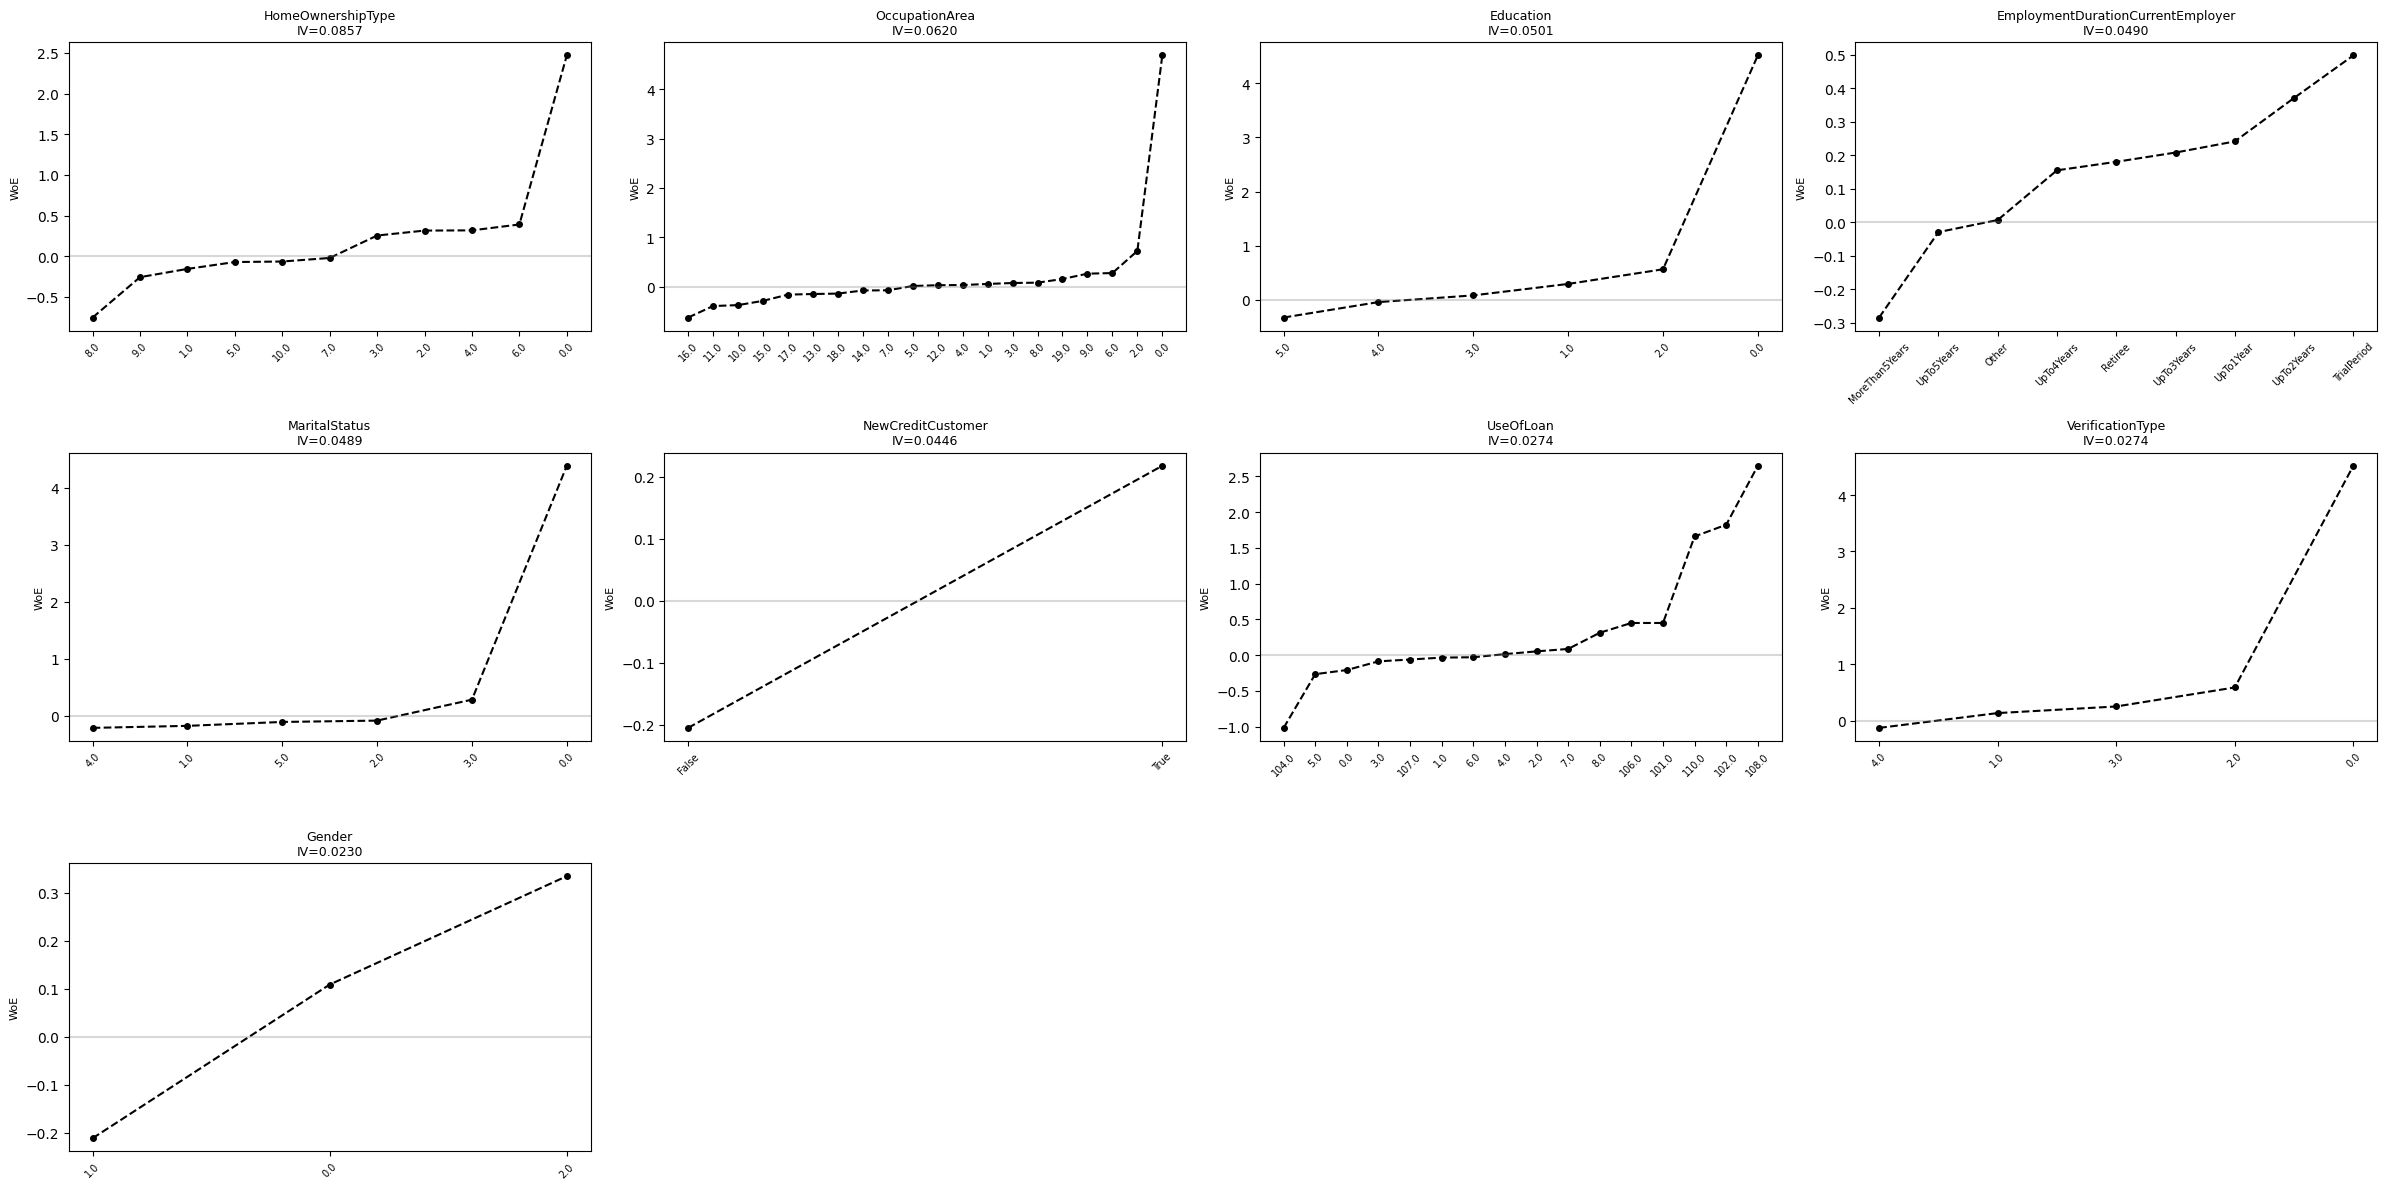

In [20]:

# WoE pattern plots — visually check monotonicity in categorical variables

cat_detail_tables = {}

for col in cat_selected:
    # 1. Filter out missing values (if any)
    valid = X_train[col].notna() & y_train.notna()
    
    # 2. Pass the raw categorical column directly to the detail table
    cat_detail_tables[col] = woe_detail_table(
        X_train.loc[valid, col], 
        y_train.loc[valid], 
        variable_name=col
    )

# Plot the categoricals
fig = plot_woe_grid(cat_detail_tables, cols_per_row=4)
fig.savefig(PATHS['reports_dir'] / 'figures' / 'woe_categorical_patterns.png', dpi=150, bbox_inches='tight')


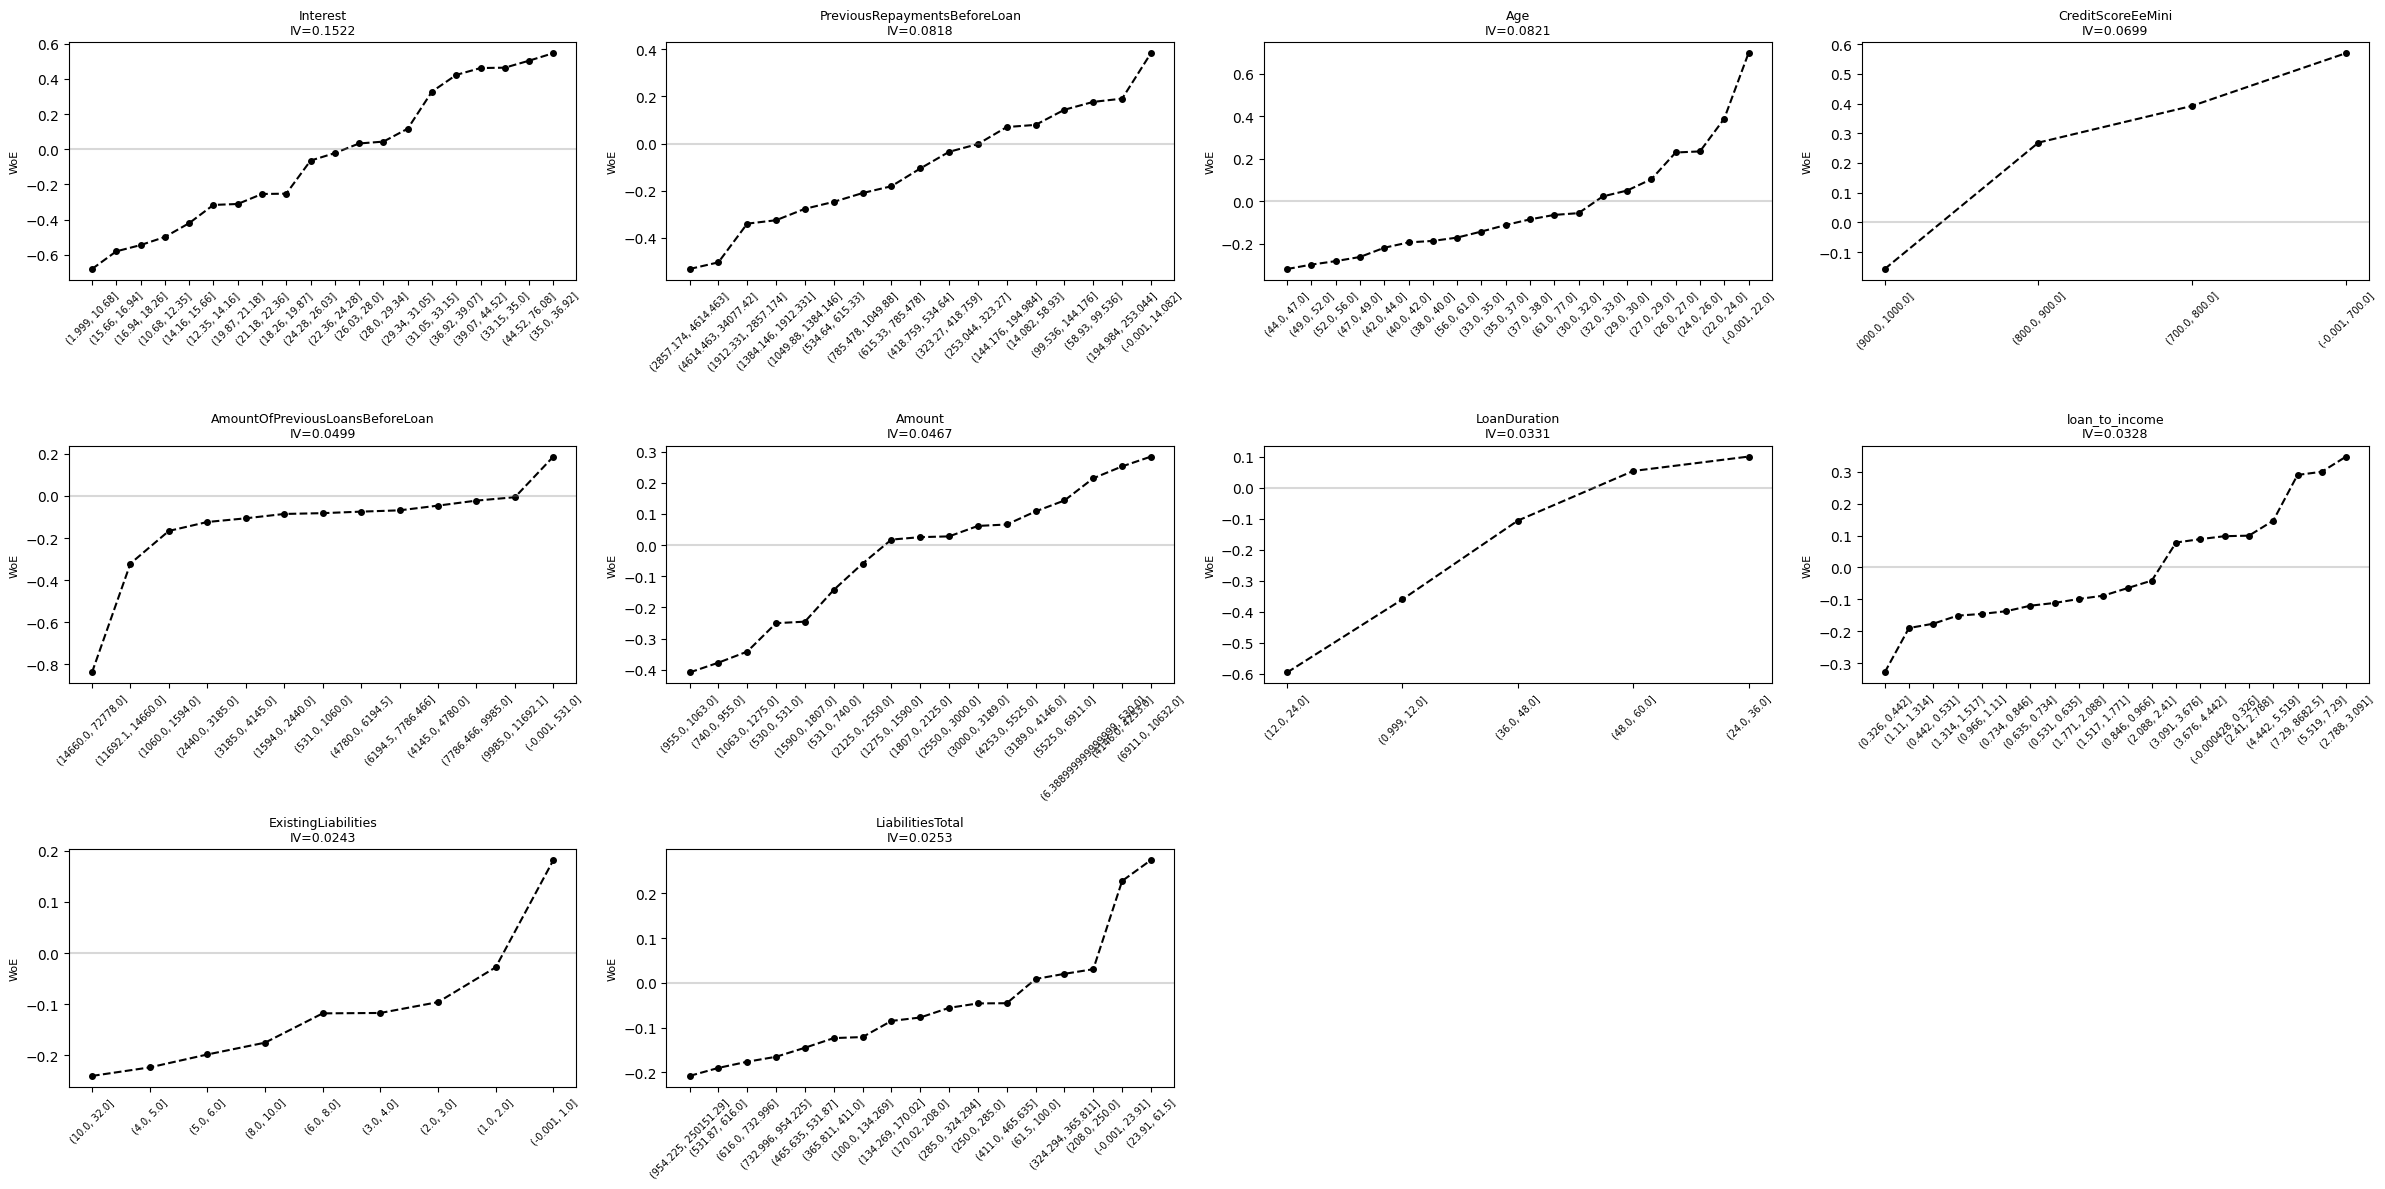

In [21]:
# Fine binning (20 bins) — see the raw shape before deciding what to merge
cont_detail_tables = {}
for col in cont_selected:
    binned = pd.qcut(X_train[col].dropna(), q=20, duplicates='drop')
    binned = binned.reindex(X_train.index)
    valid = binned.notna()
    cont_detail_tables[col] = woe_detail_table(binned[valid], y_train[valid], variable_name=col)

fig = plot_woe_grid(cont_detail_tables, cols_per_row=4)
fig.savefig(PATHS['reports_dir'] / 'figures' / 'woe_quantile_continuous_fine.png', dpi=150, bbox_inches='tight')


# 5A Manual Binning Overrides

#### Due to time constraint, didn't get to bin manually :(
    Skipping manual binning features for now

In [22]:

# How to : adjust the edges for each variable based on what can be observed in the plots. 


In [25]:
# interest_mapping = {
#     # Group 1
#     '(1.999, 10.68]': 'Group_1_Lowest',
#     '(15.66, 16.94]': 'Group_1_Lowest',
    
#     # Group 2
#     '(16.94, 18.26]': 'Group_2',
#     '(10.68, 12.35]': 'Group_2',
#     '(14.16, 15.66]': 'Group_2',
    
#     # Group 3
#     '(12.35, 14.16]': 'Group_3',
#     '(19.87, 21.18]': 'Group_3',
#     '(21.18, 22.36]': 'Group_3',
    
#     # Group 4 (Spanning across 0 on the y-axis)
#     '(18.26, 19.87]': 'Group_4',
#     '(24.28, 26.03]': 'Group_4',
#     '(22.26, 24.28]': 'Group_4',
#     '(26.03, 28.0]':  'Group_4',
    
#     # Group 5
#     '(28.0, 29.34]':  'Group_5',
#     '(29.34, 31.05]': 'Group_5', 
    
#     # Group 6
#     '(31.05, 33.15]': 'Group_6',
#     '(36.92, 39.07]': 'Group_6',
#     '(39.07, 44.52]': 'Group_6',
#     '(33.15, 35.0]':  'Group_6',
    
#     # Group 7
#     '(44.52, 76.08]': 'Group_7_Highest_WoE',
#     '(35.0, 36.92]':  'Group_7_Highest_WoE'
# }

# PATH B — TREE-BASED BINNING
# 5B. WoE — Tree-Based Binning

The tree decides where to split each continuous variable to best
<br>separate defaults from non-defaults. Produces fewer, more meaningful
<br>bins than quantile approach. Categoricals are unchanged.

In [26]:

woe_rules_t, iv_df_t = fit_woe(
    X_train, y_train,
    continuous_cols=CONTINUOUS_FEATURES,
    categorical_cols=CATEGORICAL_FEATURES,
    binning='tree',
    n_bins=5  # max_leaf_nodes — tree may use fewer if splits aren't informative
)

print("\n--- IV Summary (Tree) ---")
print(iv_df_t.to_string(index=False))

selected_vars_t = select_by_iv(iv_df_t, threshold=IV_THRESHOLD)


--- Computing WoE / IV on Training Set (Binning: tree) ---
  Age                                      IV = 0.0788
  Amount                                   IV = 0.0427
  Interest                                 IV = 0.1476
  LoanDuration                             IV = 0.0392
  IncomeTotal                              IV = 0.0156
  LiabilitiesTotal                         IV = 0.0260
  DebtToIncome                             IV = 0.0051
  FreeCash                                 IV = 0.0066
  ExistingLiabilities                      IV = 0.0252
  RefinanceLiabilities                     IV = 0.0001
  AmountOfPreviousLoansBeforeLoan          IV = 0.0525
  PreviousRepaymentsBeforeLoan             IV = 0.0824
  CreditScoreEeMini                        IV = 0.0699
  loan_to_income                           IV = 0.0319
  approval_ratio                           IV = 0.0170
  NewCreditCustomer                        IV = 0.0446
  VerificationType                         IV = 0.0274
  Lan

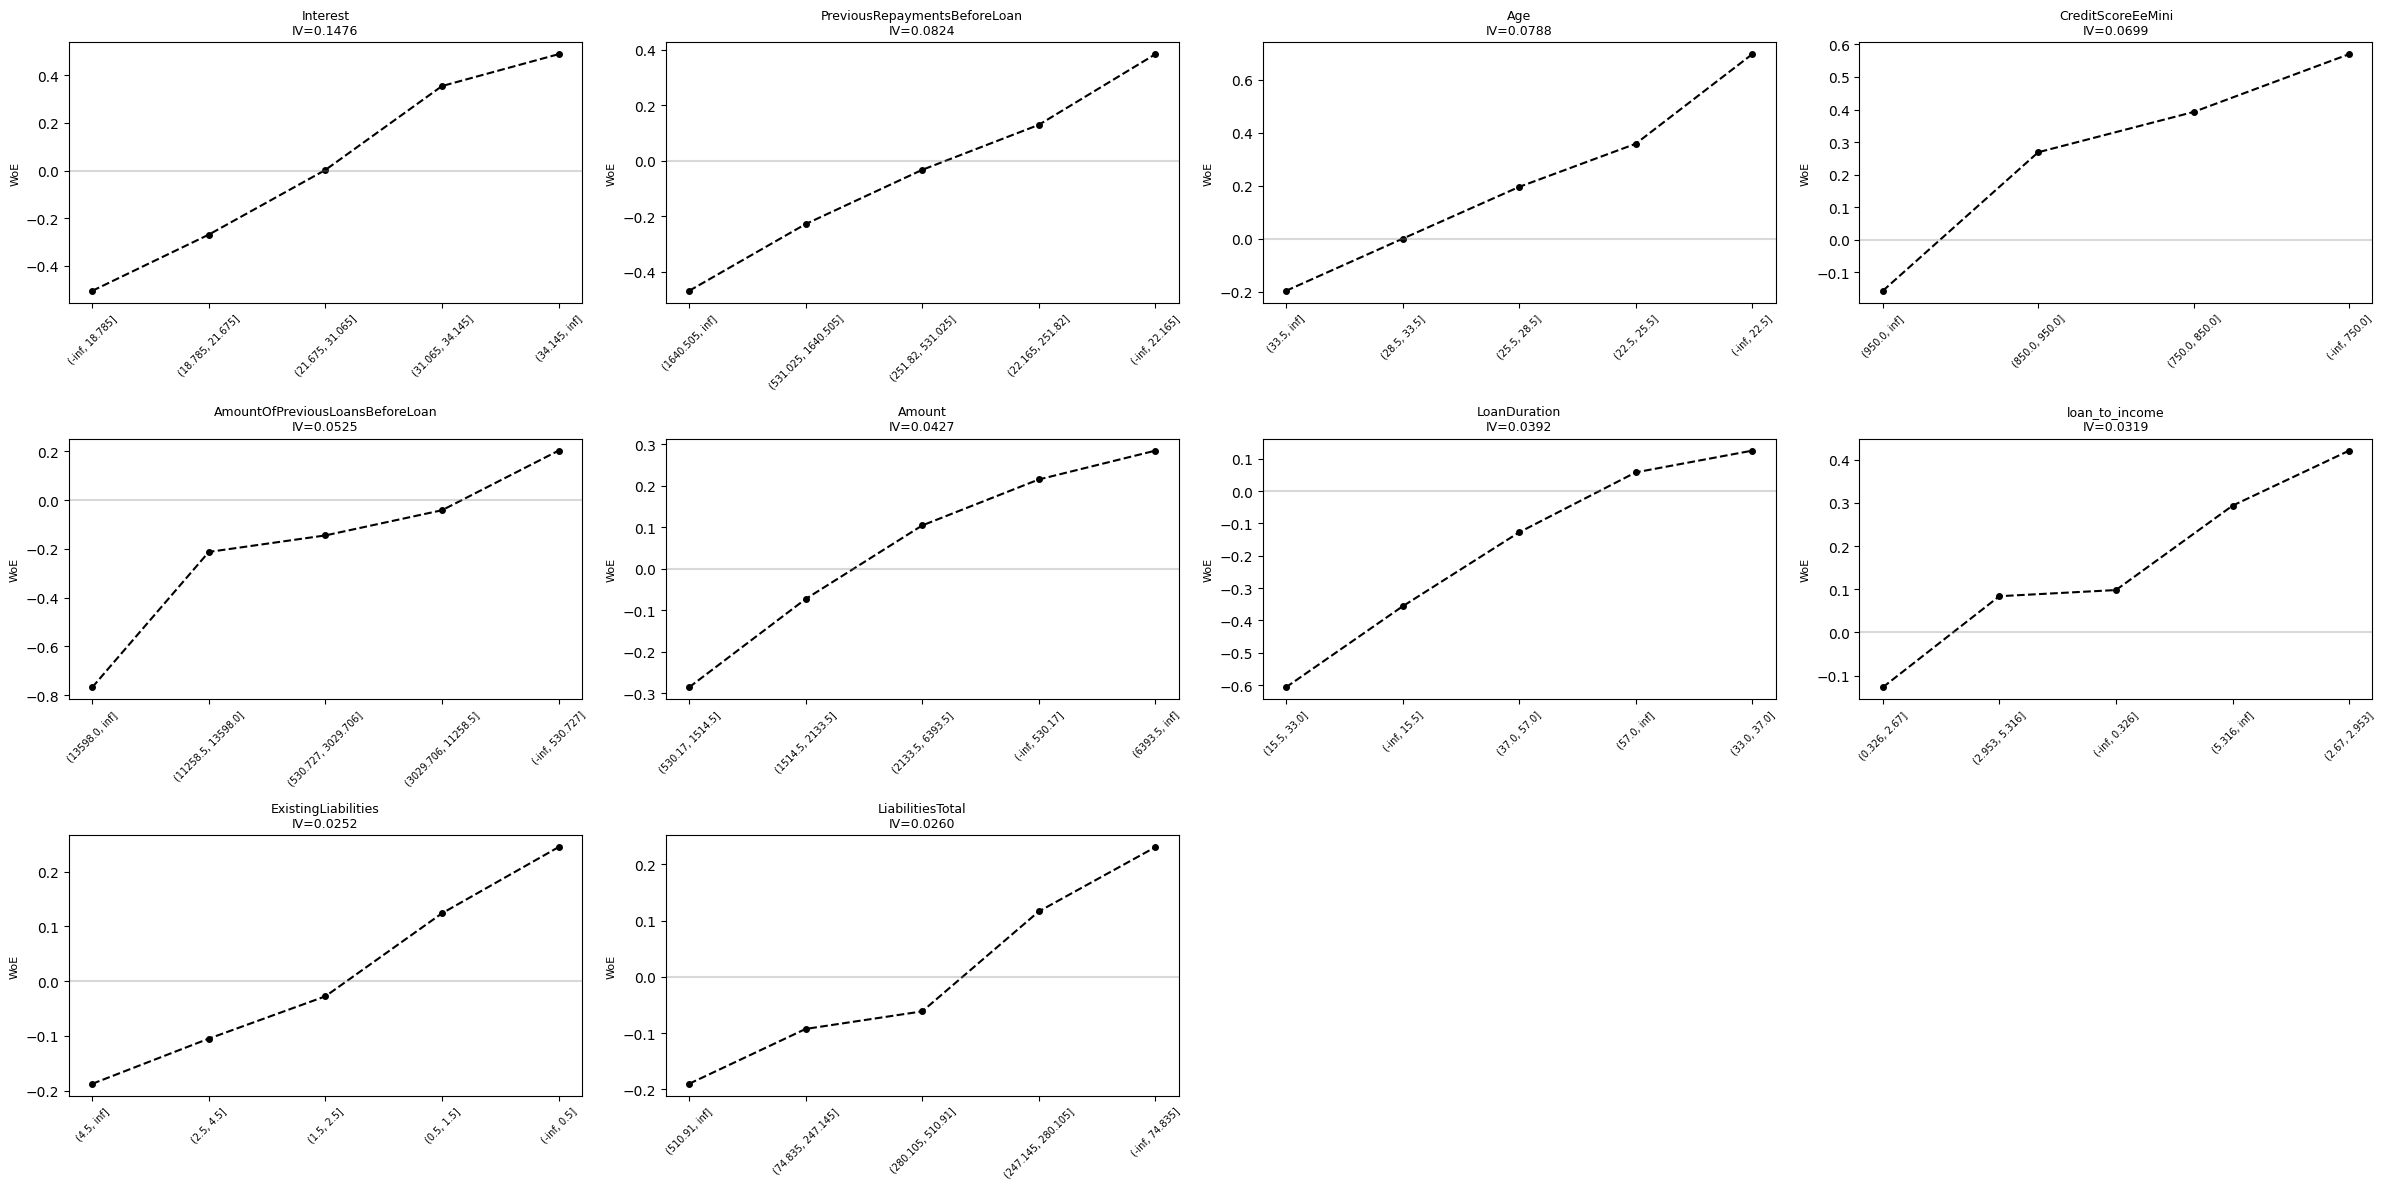

In [27]:
cont_tables_t = woe_detail_all(
    X_train, y_train,
    continuous_cols=cont_selected,
    categorical_cols=[],
    binning='tree',
    n_bins=5,
)
fig = plot_woe_grid(cont_tables_t, cols_per_row=4)
fig.savefig(PATHS['reports_dir'] / 'figures' / 'woe_tree_continuous.png', dpi=150, bbox_inches='tight')

### 5B.2 Transform & VIF — Tree Path

In [28]:
X_train_woe_t = transform_woe(X_train, woe_rules_t, selected_vars_t)
X_val_woe_t   = transform_woe(X_val,   woe_rules_t, selected_vars_t)
X_oot_woe_t   = transform_woe(X_oot,   woe_rules_t, selected_vars_t)

In [29]:
print(f"Tree WoE features: {X_train_woe_t.shape[1]}")

Tree WoE features: 19


In [30]:
vif_df_t, high_vif_t = check_vif(X_train_woe_t, threshold=VIF_THRESHOLD)

if high_vif_t:
    print(f"\nDropping high-VIF (tree): {high_vif_t}")
    X_train_woe_t.drop(columns=high_vif_t, inplace=True)
    X_val_woe_t.drop(columns=high_vif_t, inplace=True)
    X_oot_woe_t.drop(columns=high_vif_t, inplace=True)
    print(f"Final tree WoE features: {X_train_woe_t.shape[1]}")


--- VIF Check on WoE Features ---
                              Feature      VIF
              ExistingLiabilities_woe 3.107270
                NewCreditCustomer_woe 2.616842
                 LiabilitiesTotal_woe 2.383884
  AmountOfPreviousLoansBeforeLoan_woe 1.821685
     PreviousRepaymentsBeforeLoan_woe 1.693977
                              Age_woe 1.354768
                         Interest_woe 1.309960
                           Amount_woe 1.276559
                   loan_to_income_woe 1.254602
                HomeOwnershipType_woe 1.187896
EmploymentDurationCurrentEmployer_woe 1.169277
                        Education_woe 1.136225
                   OccupationArea_woe 1.109735
                CreditScoreEeMini_woe 1.109425
                 VerificationType_woe 1.086682
                    MaritalStatus_woe 1.083624
                     LoanDuration_woe 1.061623
                           Gender_woe 1.056365
                        UseOfLoan_woe 1.052560

All VIF values < 5.0 — n

# Export 

In [31]:
# %%
final_dir = PATHS['final_dir']
final_dir.mkdir(parents=True, exist_ok=True)


# --- Raw splits (XGBoost) ---
X_train.drop(columns=LEAKAGE_COLUMNS, inplace=True, errors='ignore')
X_train.to_parquet(final_dir / 'X_train.parquet', index=False)
X_val.drop(columns=LEAKAGE_COLUMNS, inplace=True, errors='ignore')
X_val.to_parquet(final_dir / 'X_val.parquet', index=False)
X_oot.drop(columns=LEAKAGE_COLUMNS, inplace=True, errors='ignore')
X_oot.to_parquet(final_dir / 'X_oot.parquet', index=False)

y_train.to_frame().to_parquet(final_dir / 'y_train.parquet', index=False)
y_val.to_frame().to_parquet(final_dir / 'y_val.parquet', index=False)
y_oot.to_frame().to_parquet(final_dir / 'y_oot.parquet', index=False)

# --- Path A: Manual Binning WoE --- 
# X_train_woe_q.to_parquet(final_dir / 'X_train_woe_quantile.parquet', index=False)
# X_val_woe_q.to_parquet(final_dir / 'X_val_woe_quantile.parquet', index=False)
# X_oot_woe_q.to_parquet(final_dir / 'X_oot_woe_quantile.parquet', index=False)
# joblib.dump(woe_rules_q, final_dir / 'woe_rules_quantile.joblib')
# joblib.dump(selected_vars_q, final_dir / 'selected_vars_quantile.joblib')

# --- Path B: Tree WoE ---
X_train_woe_t.to_parquet(final_dir / 'X_train_woe_tree.parquet', index=False)
X_val_woe_t.to_parquet(final_dir / 'X_val_woe_tree.parquet', index=False)
X_oot_woe_t.to_parquet(final_dir / 'X_oot_woe_tree.parquet', index=False)
joblib.dump(woe_rules_t, final_dir / 'woe_rules_tree.joblib')
joblib.dump(selected_vars_t, final_dir / 'selected_vars_tree.joblib')

print(f"\n✓ All outputs saved to {final_dir}/")
print(f"  Raw:     X_train ({X_train.shape}), X_val ({X_val.shape}), X_oot ({X_oot.shape})")
# print(f"  Quantile WoE: train ({X_train_woe_q.shape}), val ({X_val_woe_q.shape}), oot ({X_oot_woe_q.shape})")
print(f"  Tree WoE:     train ({X_train_woe_t.shape}), val ({X_val_woe_t.shape}), oot ({X_oot_woe_t.shape})")






✓ All outputs saved to /home/me/Documents/Coding/Projects/pd_model/data/03_final/
  Raw:     X_train ((109035, 39)), X_val ((16348, 39)), X_oot ((19646, 39))
  Tree WoE:     train ((109035, 19)), val ((16348, 19)), oot ((19646, 19))
